# Research Assistant

## Review

We will explore key LangGraph themes in this exercise:

* Memory  
* Human-in-the-loop  
* Controllability  

By integrating these concepts, we’ll tackle one of AI’s most impactful applications: research automation.

Research is often a time-consuming task, traditionally handled by analysts. AI offers significant potential to streamline this process. However, effective research demands customization, as raw LLM outputs alone often fall short for real-world decision-making.

One promising approach is AI-driven research and report generation workflows. These can be tailored to analyze emerging trends and technological innovations by leveraging structured and unstructured data sources, such as company websites, product documentation, and market reports.

In our case, we will explore how to recommend and predict future opportunities by analyzing companies working with satellite image segmentation technologies—including semantic, instance, and panoptic segmentation—over the past few years.

Analyzing these companies could help identify:

* Key startups and established companies leading in satellite image segmentation  
* Products, platforms, and services offered, including differentiating features  
* Pricing models, licensing strategies, and subscription structures  
* Industry adoption trends across defense, agriculture, climate monitoring, urban planning, and commercial sectors  

By combining memory, human oversight, and controllability, AI-powered research workflows can provide actionable insights on market positioning, product strategy, and competitive intelligence, transforming how industries approach strategic decision-making in geospatial technologies.


## Goal

Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.

`Source Selection` 
* Users can choose any set of input sources for their research.
  
`Planning` 
* Users provide a topic, and the system generates a team of AI analysts, each focusing on one sub-topic.
* `Human-in-the-loop` will be used to refine these sub-topics before research begins.
  
`LLM Utilization`
* Each analyst will conduct in-depth interviews with an expert AI using the selected sources.
* The interview will be a multi-turn conversation to extract detailed insights as shown in the [STORM](https://github.com/langchain-ai/langgraph/blob/main/examples/storm/storm.ipynb) paper.
* These interviews will be captured in a using `sub-graphs` with their internal state. 
   
`Research Process`
* Experts will gather information to answer analyst questions in `parallel`.
* And all interviews will be conducted simultaneously through `map-reduce`.

`Output Format` 
* The gathered insights from each interview will be synthesized into a final report.
* We'll use customizable prompts for the report, allowing for a flexible output format. 

![Screenshot 2024-08-26 at 7.26.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb164d61c93d48e604091_research-assistant1.png)

In [1]:
# %%capture --no-stderr
# %pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia

## Setup

In [2]:
import os, getpass
from dotenv import load_dotenv
from langchain_openai import AzureChatOpenAI

# Load environment variables from .env file
load_dotenv()

# Get API keys and settings from environment variables
tavily_api_key = os.getenv("TAVILY_API_KEY")

azure_api_key = os.getenv("AZURE_API_KEY")
azure_base_url = os.getenv("AZURE_ENDPOINT")
azure_deployment_name = os.getenv("DEPLOYMENT_NAME")
azure_api_version = os.getenv("API_VERSION")


In [3]:
# Initialize the Azure OpenAI LLM
llm = AzureChatOpenAI(
    openai_api_key=azure_api_key,
    azure_endpoint=azure_base_url,
    deployment_name=azure_deployment_name,
    openai_api_version=azure_api_version
)

In [4]:
# Ask a question for checking
# response = llm.invoke("What is the capital of Germany?")

# # Print the response
# print(response)

## Generate Analysts: Human-In-The-Loop

Create analysts and review them using human-in-the-loop.

In [5]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Analyst(BaseModel):
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    name: str = Field(
        description="Name of the analyst."
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

class GenerateAnalystsState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

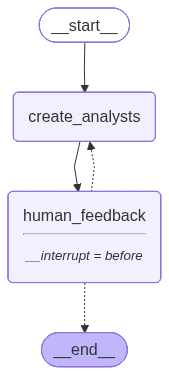

In [6]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

analyst_instructions = """You are tasked with creating a set of AI analyst personas to study companies working with satellite 
image segmentation technologies. Follow these instructions carefully:

1. Review the research topic:  
   {topic}  

2. Examine any editorial feedback that has been optionally provided to guide the creation of the analysts:  
   {human_analyst_feedback}  

3. Analyze companies that develop or utilize satellite imagery for semantic segmentation, instance segmentation, 
   and panoptic segmentation.  

4. Select the top {max_analysts} themes from the following focus areas:  
   - Startups and established companies building products with satellite image segmentation  
   - Key products, platforms, and services related to semantic, instance, and panoptic segmentation  
   - Pricing models, licensing, or subscription structures adopted by these companies  
   - Differentiators in product capabilities (e.g., accuracy, scalability, integration with geospatial platforms)  
   - Industry applications and customer adoption trends across defense, agriculture, climate monitoring, 
     urban planning, and commercial sectors  

5. Assign one analyst persona to each selected theme, ensuring that they specialize in extracting meaningful 
insights relevant to market positioning, product strategy, and competitive landscape analysis."""


def create_analysts(state: GenerateAnalystsState):
    
    """ Create analysts """
    
    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback', '')
        
    # Enforce structured output
    structured_llm = llm.with_structured_output(Perspectives)

    # System message
    system_message = analyst_instructions.format(topic=topic,
                                                            human_analyst_feedback=human_analyst_feedback, 
                                                            max_analysts=max_analysts)

    # Generate question 
    analysts = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

def human_feedback(state: GenerateAnalystsState):
    """ No-op node that should be interrupted on """
    pass

def should_continue(state: GenerateAnalystsState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # Otherwise end
    return END

# Add nodes and edges 
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [7]:
# Input
# I used two analysts in order to minimize the cost. 
max_analysts = 3 
topic = "Analysis of companies developing satellite image segmentation technologies (semantic, instance, and panoptic), including their products, pricing models, and adoption trends across industries."
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Sophia Carter
Affiliation: GeoTech Analytics
Role: Market Positioning Specialist
Description: Sophia focuses on startups and established companies creating satellite image segmentation products. Her analyses aim to uncover market positioning strategies and identify competitive advantages in the domain of geospatial technologies.
--------------------------------------------------
Name: Liam Patel
Affiliation: Spatial Insight Partners
Role: Product Strategy Analyst
Description: Liam specializes in evaluating key products, platforms, and services related to semantic, instance, and panoptic segmentation. He provides insights into product innovation, technological differentiation, and strategic alignment with industry needs.
--------------------------------------------------
Name: Olivia Zhang
Affiliation: Orbital Data Consultancy
Role: Competitive Landscape Expert
Description: Olivia examines industry applications and customer adoption trends for satellite image segmentation technolo

In [8]:
# Get state and look at next node
state = graph.get_state(thread)
state.next

('human_feedback',)

In [9]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                            "Add someone from a startup working on satellite image segmentation to provide an entrepreneurial perspective and predict future product and pricing trends"}, as_node="human_feedback")



{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08095c-47aa-640a-8002-df406c4459ef'}}

In [10]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Sophia Carter
Affiliation: GeoTech Analytics
Role: Market Positioning Specialist
Description: Sophia focuses on startups and established companies creating satellite image segmentation products. Her analyses aim to uncover market positioning strategies and identify competitive advantages in the domain of geospatial technologies.
--------------------------------------------------
Name: Liam Patel
Affiliation: Spatial Insight Partners
Role: Product Strategy Analyst
Description: Liam specializes in evaluating key products, platforms, and services related to semantic, instance, and panoptic segmentation. He provides insights into product innovation, technological differentiation, and strategic alignment with industry needs.
--------------------------------------------------
Name: Olivia Zhang
Affiliation: Orbital Data Consultancy
Role: Competitive Landscape Expert
Description: Olivia examines industry applications and customer adoption trends for satellite image segmentation technolo

In [11]:
# If we are satisfied, then we simply supply no feedback
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08095c-583f-6f36-8004-61603fd26fe6'}}

In [12]:
# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [13]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

In [14]:
final_state.next

()

In [15]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Sophia Carter
Affiliation: Geospatial Technology Startup
Role: Entrepreneurial Analyst
Description: Sophia brings insights into startups developing satellite image segmentation technologies, focusing on innovation, market trends, and predicting future product and pricing strategies.
--------------------------------------------------
Name: Daniel Lee
Affiliation: Industry Research Firm
Role: Product Strategy Analyst
Description: Daniel specializes in evaluating key products, platforms, and services related to semantic, instance, and panoptic segmentation, identifying differentiators in their capabilities and integration potential.
--------------------------------------------------
Name: Priya Sharma
Affiliation: Market Intelligence Agency
Role: Market Adoption Analyst
Description: Priya focuses on understanding industry applications and customer adoption trends across defense, agriculture, climate monitoring, urban planning, and commercial sectors.
--------------------------------

## Conduct Interview

### Generate Question

The analyst will ask questions to the expert.

In [16]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [17]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about 
companies developing satellite image segmentation technologies (semantic, instance, and panoptic).

Your goal is to extract interesting and specific insights related to the following focus areas:

1. **Startups and established companies building products with satellite image segmentation**  
2. **Key products, platforms, and services related to semantic, instance, and panoptic segmentation**  
3. **Pricing models, licensing, or subscription structures adopted by these companies**  
4. **Differentiators in product capabilities (e.g., accuracy, scalability, integration with geospatial platforms)**  
5. **Industry applications and customer adoption trends across defense, agriculture, climate monitoring, 
   urban planning, and commercial sectors**  

Your insights should be:  

- **Interesting:** Insights that people will find surprising or non-obvious.  
- **Specific:** Insights that avoid generalities and include concrete product examples, company names, 
  pricing details, or adoption cases from the expert.  

Here are your goals for this interview: {goals}

Begin by introducing yourself using a name that fits your persona, and then ask your first question.  

Continue to ask follow-up questions to drill down and refine your understanding of the topic.  

When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your responses, reflecting the persona and goals provided to you."""


def generate_question(state: InterviewState):
    """ Node to generate a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]

    # Generate question 
    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
        
    # Write messages to state
    return {"messages": [question]}

### Generate Answer: Parallelization

The expert will gather information from multiple sources in parallel to answer questions.

For example, we can use:

* Specific web sites e.g., via [`WebBaseLoader`](https://python.langchain.com/v0.2/docs/integrations/document_loaders/web_base/)
* Indexed documents e.g., via [RAG](https://python.langchain.com/v0.2/docs/tutorials/rag/)
* Web search
* Wikipedia search

Try different web search tools, I used Tavily: [Tavily](https://tavily.com/).

In [18]:
tavily_api_key = os.getenv('AVILY_API_KEY')

In [19]:
# Web search tool
from langchain_community.tools.tavily_search import TavilySearchResults
# I used two search in order to minimize the cost.
tavily_search = TavilySearchResults(max_results=2)

In [20]:
# Wikipedia search tool
from langchain_community.document_loaders import WikipediaLoader

Now, we create nodes to search the web and wikipedia.

We'll also create a node to answer analyst questions.

Finally, we'll create nodes to save the full interview and to write a summary ("section") of the interview.

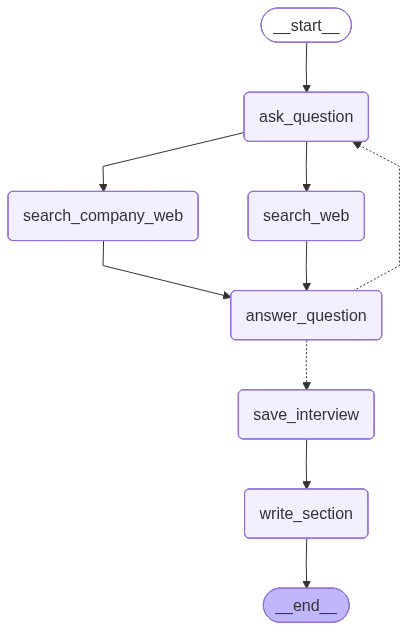

In [21]:
from langchain_core.messages import get_buffer_string
from langchain_community.document_loaders import ArxivLoader
#from langchain_community.document_loaders import CrunchbaseLoader

# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in a web search to find information about companies, 
products, pricing models, and adoption trends related to the conversation topic.

First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a clear, specific web search query 
that would retrieve company websites, product documentation, pricing pages, or market news.""")


def search_web(state: InterviewState):
    
    """ Retrieve docs from web search """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # Search
    search_docs = tavily_search.invoke(search_query.search_query)

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

# def search_arxiv(state: InterviewState):
#     """ Retrieve docs from arXiv (research papers) """

#     structured_llm = llm.with_structured_output(SearchQuery)
#     search_query = structured_llm.invoke([search_instructions] + state['messages'])

#     # Search in arXiv
#     search_docs = ArxivLoader(query=search_query.search_query, load_max_docs=2).load()

#     formatted_search_docs = "\n\n---\n\n".join(
#         [
#             f'<Document source="{doc.metadata.get("source", "arxiv")}" title="{doc.metadata.get("title", "")}"/>\n{doc.page_content}\n</Document>'
#             for doc in search_docs
#         ]
#     )

#     return {"context": [formatted_search_docs]}

def search_company_web(state: InterviewState):
    """ Retrieve company/product/pricing info from web search """
    
    structured_llm = llm.with_structured_output(SearchQuery)
    
    # Use the same search instructions already defined
    search_query = structured_llm.invoke([search_instructions] + state['messages'])
    
    # Use Tavily or any other web search API
    search_docs = tavily_search.invoke(search_query.search_query)
    
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}


    

answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

def generate_answer(state: InterviewState):
    
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    return "ask_question"

section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up the summary with general background / context related to companies developing satellite image segmentation (semantic, instance, panoptic)  
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview and source documents  
- Include details on products, pricing models, differentiators, and adoption trends where relevant  
- Create a numbered list of source documents, as you use them  
- Do not mention the names of interviewers or experts  
- Aim for approximately 400 words maximum  
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report  
- Provide full links to relevant websites or specific document paths  
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.  
- It will look like:

### Sources
[1] Link or Document name  
[2] Link or Document name  

7. Be sure to combine sources. For example this is not correct:

[3] https://orbitalinsight.com/products  
[4] https://orbitalinsight.com/products  

There should be no redundant sources. It should simply be:

[3] https://orbitalinsight.com/products  
        
8. Final review:
- Ensure the report follows the required structure  
- Include no preamble before the title of the report  
- Check that all guidelines have been followed"""

def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

# Add nodes and edges 
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_company_web", search_company_web)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# Flow
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_company_web")
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_company_web", "answer_question")
interview_builder.add_conditional_edges("answer_question", route_messages,['ask_question','save_interview'])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# Interview 
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

# View
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [22]:
# Pick one analyst
analysts[0]

Analyst(affiliation='Geospatial Technology Startup', name='Sophia Carter', role='Entrepreneurial Analyst', description='Sophia brings insights into startups developing satellite image segmentation technologies, focusing on innovation, market trends, and predicting future product and pricing strategies.')

Here, we run the interview passing an index of the llama3.1 paper, which is related to our topic.

In [23]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "1"}}
interview = interview_graph.invoke({"analyst": analysts[0], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

## Innovations in Satellite Image Segmentation: Market Trends and Future Insights  

### Summary  

Satellite image segmentation has become a cornerstone of modern geospatial analytics, driven by advancements in artificial intelligence and deep learning. This technology enables industries to derive actionable insights from vast amounts of Earth observation data, serving diverse applications such as agriculture, urban planning, disaster management, and defense. Companies are leveraging three main segmentation techniques—semantic, instance, and panoptic segmentation—to enhance decision-making capabilities and automate complex workflows [1][2].  

One notable innovation is panoptic segmentation, which combines semantic and instance segmentation to classify every pixel in an image as either a "thing" (individual objects like cars or trees) or "stuff" (amorphous regions like sky or grass). This approach allows systems to capture both object-specific details and broader contextual information, improving the accuracy of geospatial analyses [2].  

A standout player in this domain is FlyPix AI, which offers a no-code platform for AI-driven geospatial imagery analysis. The platform enables users to train custom AI models for object detection without programming expertise. FlyPix AI provides tiered pricing plans, ranging from a free basic option to an enterprise-level solution tailored to specific organizational needs. Higher tiers offer features such as multispectral data analysis and API access, catering to industries like agriculture, construction, and government [3][4].  

Meanwhile, Hitech BPO specializes in customizing segmentation models for specific industry needs, ensuring alignment with project goals and data operation strategies. Their services span semantic, instance, and panoptic segmentation, delivering in-depth visual insights that enhance operational efficiency [3].  

Digital Sense focuses on end-to-end solutions, offering satellite sensor calibration, application-level analytics, and scalable implementation. Their emphasis on customization, data security, and external technology integration (e.g., GIS systems) positions them as key enablers for industries like AgriTech and urban planning [1].  

Pricing strategies across the sector reflect a balance between accessibility and scalability. FlyPix AI's entry-level plans cater to smaller projects with basic analytics tools, while enterprise-level plans offer advanced features such as higher-resolution imagery and dedicated support for large-scale initiatives [4]. Adoption trends indicate a steady increase in demand from commercial and governmental sectors, fueled by the growing need for precise monitoring, disaster response, and environmental sustainability [1][3].  

### Sources  
[1] https://flypix.ai/blog/satellite-image-processing-companies/  
[2] https://viso.ai/deep-learning/panoptic-segmentation/  
[3] https://www.hitechbpo.com/image-segmentation-services.php  
[4] https://flypix.ai/blog/satellite-imagery-software-tools-ai/  

### Parallelze interviews: Map-Reduce

We parallelize the interviews via the `Send()` API, a map step.

We combine them into the report body in a reduce step.

### Finalize

We add a final step to write an intro and conclusion to the final report.

In [24]:
import operator
from typing import List, Annotated
from typing_extensions import TypedDict

class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report

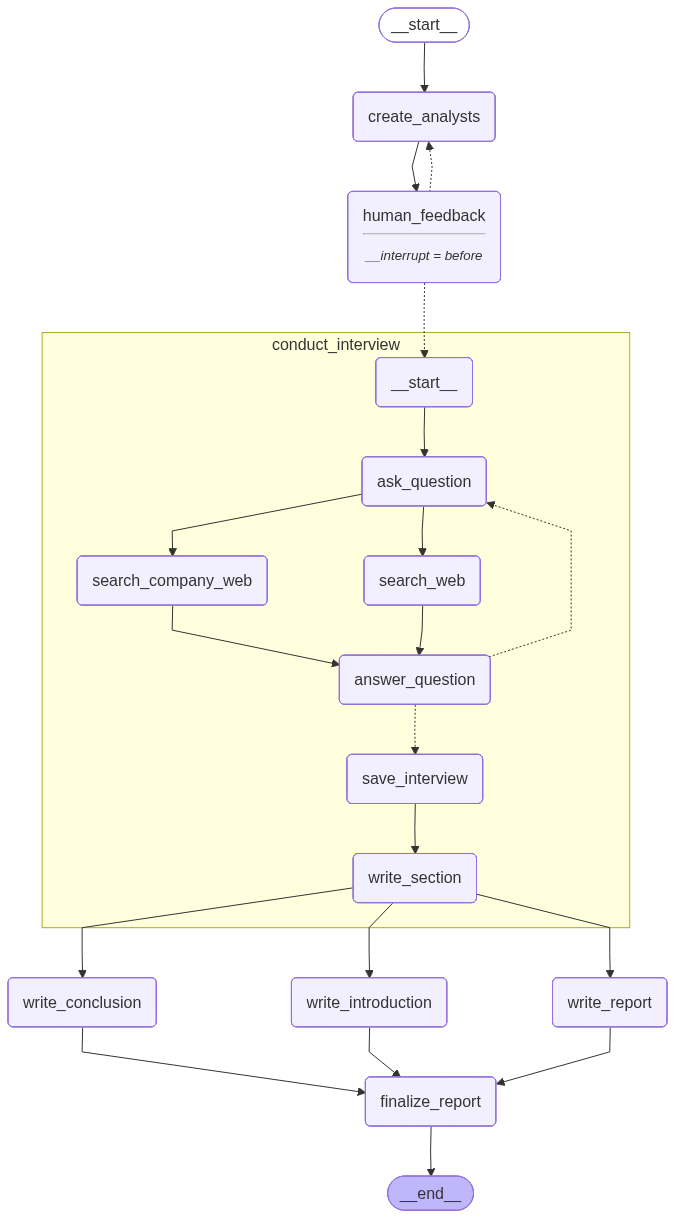

In [25]:
from langgraph.constants import Send

def initiate_all_interviews(state: ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """    

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"

    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                           "messages": [HumanMessage(
                                               content=f"So you said you were writing an article on {topic}?"
                                           )
                                                       ]}) for analyst in state["analysts"]]

report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic related to satellite image segmentation companies (semantic, instance, and panoptic).  
2. They wrote up their findings into a memo.  

Your task: 

1. You will be given a collection of memos from your analysts.  
2. Think carefully about the insights from each memo.  
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos.  
4. Summarize the central points in each memo into a cohesive single narrative, highlighting:  
   - Companies (startups and established players)  
   - Products, platforms, and services  
   - Pricing models and licensing strategies  
   - Differentiators in technology and performance  
   - Adoption trends and industry applications  

To format your report:
 
1. Use markdown formatting.  
2. Include no pre-amble for the report.  
3. Use no sub-heading except those specified.  
4. Start your report with a single title header: ## Insights  
5. Do not mention any analyst names in your report.  
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].  
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.  
8. List your sources in order and do not repeat.  

## Sources  
[1] Source 1  
[2] Source 2  

Here are the memos from your analysts to build your report from:  

{context}"""


def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [26]:
# Inputs
max_analysts = 3 
topic = "Analysis of companies developing satellite image segmentation technologies (semantic, instance, and panoptic), including their products, pricing models, differentiators, and industry adoption trends."
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,
                           "max_analysts":max_analysts}, 
                          thread, 
                          stream_mode="values"):
    
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Ethan Clarke
Affiliation: Geospatial Analytics Institute
Role: Market Positioning Specialist
Description: Dr. Clarke focuses on analyzing the competitive landscape of companies involved in satellite image segmentation, particularly their market positioning. He evaluates startups and established companies, identifying industry leaders and challengers based on their product portfolios and strategic moves.
--------------------------------------------------
Name: Sophia Martinez
Affiliation: Remote Sensing Technologies Hub
Role: Product Strategy Analyst
Description: Sophia specializes in dissecting the key products, platforms, and services related to semantic, instance, and panoptic segmentation. She investigates their technical capabilities, integration potential, and strategic alignment with customer needs.
--------------------------------------------------
Name: Rajiv Patel
Affiliation: Global Spatial Intelligence Network
Role: Industry Trends Analyst
Description: Rajiv examin

In [27]:

graph.update_state(thread, {"human_analyst_feedback": 
                                "Include the CEO of a satellite image segmentation startup to provide an entrepreneurial perspective on products, pricing, and market trends"}, as_node="human_feedback")


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08095d-739f-61fe-8002-134a5ab9c8f1'}}

In [28]:
# Check
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Ethan Clarke
Affiliation: Geospatial Analytics Institute
Role: Market Positioning Specialist
Description: Dr. Clarke focuses on analyzing the competitive landscape of companies involved in satellite image segmentation, particularly their market positioning. He evaluates startups and established companies, identifying industry leaders and challengers based on their product portfolios and strategic moves.
--------------------------------------------------
Name: Sophia Martinez
Affiliation: Remote Sensing Technologies Hub
Role: Product Strategy Analyst
Description: Sophia specializes in dissecting the key products, platforms, and services related to semantic, instance, and panoptic segmentation. She investigates their technical capabilities, integration potential, and strategic alignment with customer needs.
--------------------------------------------------
Name: Rajiv Patel
Affiliation: Global Spatial Intelligence Network
Role: Industry Trends Analyst
Description: Rajiv examin

In [29]:
# Confirm we are happy
graph.update_state(thread, {"human_analyst_feedback": 
                            None}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08095d-85c1-65d0-8004-f250a00c7226'}}

In [30]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--
conduct_interview
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_conclusion
--Node--
write_introduction
--Node--
write_report
--Node--
finalize_report


In [31]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Decoding the Future: Satellite Image Segmentation Technologies and Trends  

## Introduction  

Satellite image segmentation technologies—semantic, instance, and panoptic—are revolutionizing industries by enabling precise geospatial analysis. This report explores the market potential of segmentation, highlighting key players like iMerit, Orbital Insight, and ICEYE, their tailored solutions, and collaborative workflows. It examines cutting-edge techniques such as Mask2Former and panoptic frameworks, which combine class categorization with object detection for unparalleled accuracy. Industry adoption trends reveal growing demand in sectors like agriculture, defense, and urban planning, fueled by advancements in AI and deep learning models. With innovative pricing models and competitive differentiation, the satellite image segmentation market emerges as a dynamic landscape poised for transformative growth.  

---



Satellite image segmentation technologies, encompassing semantic, instance, and panoptic segmentation, are transforming geospatial analysis and driving innovation across multiple industries. These segmentation methods provide granular insights from satellite imagery, enabling applications in agriculture, urban planning, defense, climate monitoring, disaster management, financial services, and commercial analytics. The market for these technologies is characterized by rapid advancements, tailored solutions, competitive differentiation, and increasing adoption across sectors.  

### Companies  

Key players in the satellite image segmentation space include both startups and established companies.  

- **iMerit**: Specializes in providing customized image segmentation services tailored to diverse client needs. The company supports semantic, instance, and panoptic segmentation and collaborates with clients to calibrate workflows based on quality and throughput requirements [1][5].  
- **Orbital Insight**: With $128.7 million in funding, this company focuses on geospatial analytics. It distinguishes itself through proprietary machine learning algorithms that extract actionable insights, such as crop yield predictions and socioeconomic trend analysis [2][3].  
- **ICEYE**: A leader in synthetic aperture radar (SAR)-based imaging, ICEYE has raised $270 million to advance microsatellite technologies for applications like space debris tracking and geospatial analytics [1].  
- **Hitech BPO**: Offers segmentation-as-a-service, including semantic, instance, and panoptic segmentation, to support AI and machine learning systems [6].  
- **L3Harris**: Provides customized geospatial solutions for simulation systems, construction planning, and defense applications, leveraging segmentation techniques for precision analytics [3].  

### Products, Platforms, and Services  

Satellite image segmentation products are built upon state-of-the-art deep learning frameworks, each optimized for specific segmentation techniques:  
- **Semantic Segmentation**: Models like U-Net, SegNet, DeepLabv3, PSPNet, and FCN enable class-level categorization of pixels. This method is widely used for terrain classification and environmental monitoring [1][2].  
- **Instance Segmentation**: Techniques such as Mask R-CNN, SOLO, and YOLACT differentiate individual objects within the same class, making them ideal for applications like object detection and disaster management [1][2].  
- **Panoptic Segmentation**: Advanced architectures like Panoptic FPN, UPSNet, DETR, and Mask2Former combine semantic and instance segmentation for comprehensive scene understanding, crucial for urban planning and climate monitoring [2][4][5].  

### Pricing Models and Licensing Strategies  

The market exhibits diverse pricing and business models suited to different client needs:  
- Companies like Hitech BPO and Roboflow offer segmentation-as-a-service platforms that integrate seamlessly into existing workflows, providing cost-effective and scalable solutions [4][6].  
- Customization and collaboration are key aspects of pricing models for companies like iMerit, which build bespoke workflows to meet specific project requirements [1][5].  

### Differentiators in Technology and Performance  

The competitive landscape is shaped by innovation in deep learning models and tailored solutions:  
- **Technology Differentiation**: Panoptic segmentation is a major area of advancement, with frameworks like Mask2Former and Panoptic FPN improving pixel-level labeling precision and efficiency [4][5].  
- **Custom Solutions**: Companies like iMerit and L3Harris gain an edge by delivering highly customizable segmentation workflows, ensuring high throughput and quality control [1][3].  
- **Scalability**: Hitech BPO’s segmentation-as-a-service model offers flexible and scalable deployment options, appealing to organizations with varying project demands [6].  

### Adoption Trends and Industry Applications  

The adoption of satellite image segmentation is growing across industries, driven by the need for actionable insights from geospatial data:  
- **Agriculture**: Technologies are used for crop monitoring, yield prediction, and resource management [2][5].  
- **Urban Planning**: Segmentation enables infrastructure development, simulation systems, and construction planning [3][5].  
- **Defense and Disaster Management**: These technologies facilitate surveillance, terrain analysis, and disaster response [3][4].  
- **Climate Monitoring**: Panoptic segmentation is particularly valuable for environmental assessments and climate research [5][6].  

Market forecasts predict significant adoption across North America, Europe, and Asia-Pacific through 2032, despite challenges such as high satellite development costs and regulatory restrictions [3]. The sector's growth is fueled by the convergence of semantic, instance, and panoptic segmentation techniques, offering unified solutions for efficient categorization, object detection, and scene understanding [2][4][5].  

### Conclusion  

The satellite image segmentation market is poised for significant growth, underpinned by technological advancements, tailored solutions, and increasing demand from diverse industries. Companies at the forefront, such as iMerit, Orbital Insight, and ICEYE, are leveraging cutting-edge tools and algorithms to meet client needs while driving innovation in the field. As segmentation models become more precise and scalable, adoption across agriculture, urban planning, defense, and climate monitoring is expected to intensify, solidifying the role of satellite image segmentation as a cornerstone of modern geospatial analytics.  

## Sources  
[1] https://imerit.net/solutions/computer-vision/image-segmentation-services/  
[2] https://pyimagesearch.com/2022/06/29/semantic-vs-instance-vs-panoptic-segmentation/  
[3] https://flypix.ai/blog/satellite-image-processing-companies/  
[4] https://openaccess.thecvf.com/content_CVPR_2019/papers/Kirillov_Panoptic_Segmentation_CVPR_2019_paper.pdf  
[5] https://www.basic.ai/blog-post/comprehensive-guide-of-panoptic-segmentation  
[6] https://www.hitechbpo.com/image-segmentation-services.php

---

## Conclusion

The satellite image segmentation market is undergoing rapid evolution, driven by advancements in semantic, instance, and panoptic segmentation techniques. These technologies are enabling granular insights across industries, including agriculture, defense, urban planning, and climate monitoring. Companies like iMerit, Orbital Insight, and ICEYE are leveraging tailored workflows, proprietary algorithms, and innovative models to address diverse customer needs. Emerging frameworks like Mask2Former and Panoptic FPN are enhancing segmentation accuracy while addressing resource challenges. With increasing adoption fueled by scalable solutions and diverse pricing models, satellite image segmentation is poised to unlock significant value across sectors, reshaping geospatial analytics and decision-making.

## Conclusion and remark: 

In the above exercise, I built a research multi-agent system using Langgraph. The graph orchestration is presented in the figure above. As mentioned in the problem statement, we will build a cost-effective model. A good aspect of the above work is that it will also provide the search link so that the user can go through it. There are a few things we can consider in order to build a cost-effective model. These are listed below:

-Restrict the number of analysts and the number of turns in the conversation.

-Restrict the number of searches.

-Select the search sources carefully. In my case, I used Google and Wikipedia, which may not be ideal for the given problem.

-Add humans in the loop (I added this in this exercise) before performing the search and doing the heavy lifting. I feel this is a very crucial step that will guide the search.

-Optimize the prompt in order to improve the quality of the output. A shorter and more concise prompt will reduce token usage and save on latency.

In the above example, I tried to implement the technique but did not perform any optimization or fine-tuning tasks. This would require more intense work, and human feedback is crucial in order to build a state-of-the-art tool.